In [9]:
from models import *

from dataloader import RelDataset

data = RelDataset('PSG', split='val')

model = LLaVAModel(device="cuda:1", region_guidance=False)

Loading data from /home/maelic/Documents/OpenVocSGG/all_annotations/psg_full.json...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

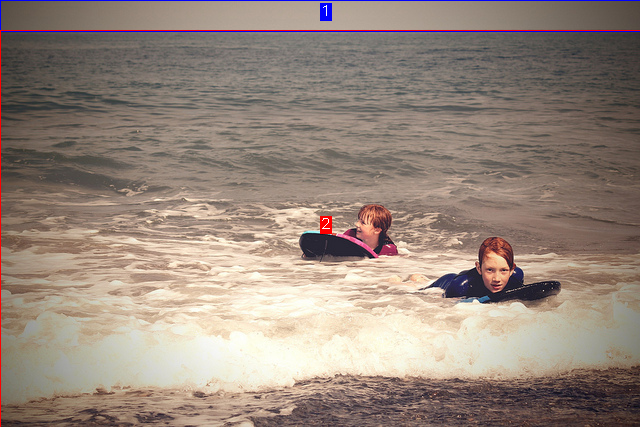

In [17]:
img_orig, img_cropped, img, pair, boxes = data.get_random_pair(intersect=True)
display(img_cropped)

None
user 
Analyze and describe the directed visual relationship between two entities in an image, focusing on Entity 1 as the subject and Entity 2 as the object. Entity 1 is represented by the blue bounding box, while Entity 2 is the red bounding box. Follow these refined steps:

1. **Entity Identification**  
   - Clearly identify each entity's visual characteristics within the image. Note attributes such as shape, size, and position, alongside any distinguishing features.

2. **Spatial Context**  
   - Analyze the positioning of the entities relative to each other. Consider aspects like distance, orientation, and whether entities overlap or are close in proximity.

3. **Functional Context**  
   - Assess any potential functional interactions. Identify actions or roles that may indicate how Entity 1 impacts or interacts with Entity 2.

4. **Integrative Reasoning**  
   - Determine whether the relationship is predominantly spatial or functional. Use the analysis from steps 1-3 to supp

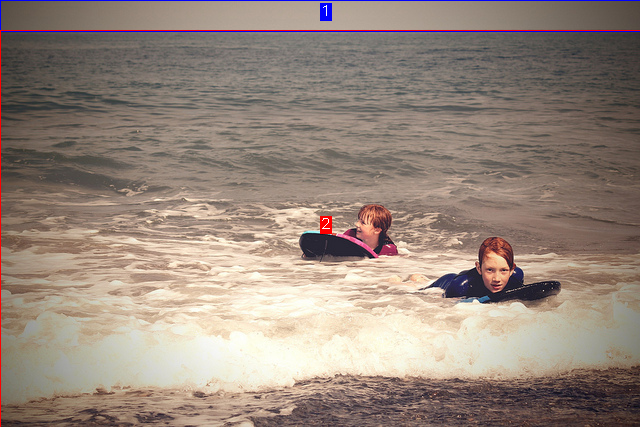

In [18]:
CoT_template = "Analyze and describe the directed visual relationship between two entities in an image, focusing on Entity 1 as the subject and Entity 2 as the object. Entity 1 is represented by the blue bounding box, while Entity 2 is the red bounding box. Follow these refined steps:\n\n1. **Entity Identification**  \n   - Clearly identify each entity's visual characteristics within the image. Note attributes such as shape, size, and position, alongside any distinguishing features.\n\n2. **Spatial Context**  \n   - Analyze the positioning of the entities relative to each other. Consider aspects like distance, orientation, and whether entities overlap or are close in proximity.\n\n3. **Functional Context**  \n   - Assess any potential functional interactions. Identify actions or roles that may indicate how Entity 1 impacts or interacts with Entity 2.\n\n4. **Integrative Reasoning**  \n   - Determine whether the relationship is predominantly spatial or functional. Use the analysis from steps 1-3 to support your reasoning and articulate it in a concise sentence.\n\nFinally, summarize the visual relationship in the format: `<sub>Entity 1</sub> <rel>relationship</rel> <obj>Entity 2</obj>`. Example: `<sub>1_person</sub> <rel>holding</rel> <obj>2_phone</obj>`.\n\n# Output Format\n\n- Provide your response as a structured sentence summarizing the relationship, followed by the formatted statement. \n\n# Notes\n\n- Ensure that the reasoning provided is comprehensive and ties together observations from all steps.\n- Consider both tangible interactions and abstract spatial nuances when formulating the result. \n Now, predict <rel></rel> for <sub>"+pair[0]+"</sub> and <obj>"+pair[1]+"</obj> based on this image. Give the output in the format: <sub>"+pair[0]+"</sub> <rel></rel> <obj>"+pair[1]+"</obj>."

output, out_raw = model.generate(pair, img_cropped, prompt_template=CoT_template)

print(output)
print(out_raw)
display(img_cropped)

above
user 
You are a robot that only outputs a relation of the form <subject, relation, object> related to an image. You reply in the following format: <sub> </sub> <rel> </rel> <obj> </obj>. You will be given the tuple <sub>, <obj> and you have to complete with the predicate <rel> </rel>. Example: <sub>person</sub> <rel>looking at</rel> <obj>dog</obj>. Now give me the relation <rel></rel> between <sub>1_sky</sub> and <obj>2_sea</obj> in this image.assistant
<sub>1_sky</sub> <rel>above</rel> <obj>2_sea</obj>


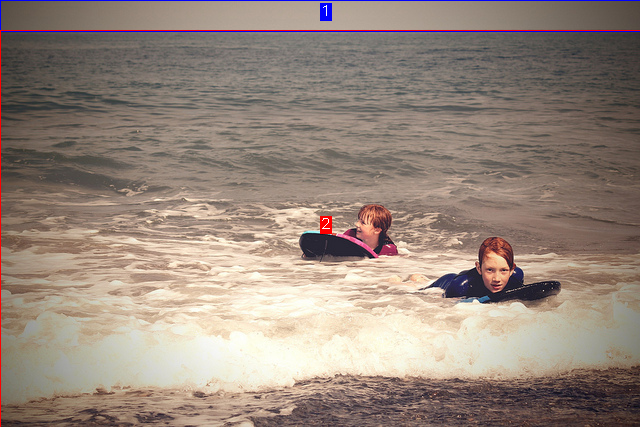

In [19]:
output, out_raw = model.generate(pair, img_cropped)

print(output)
print(out_raw)
display(img_cropped)

In [5]:
import tensorflow as tf
from PIL import Image
import requests
from transformers import AutoProcessor, AutoModel

model = AutoModel.from_pretrained("openai/clip-vit-base-patch32")
processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)

inputs = processor(
    text=["a photo of a cat", "a photo of a dog"], images=image, return_tensors="pt", padding=True
)

outputs = model(**inputs)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [6]:
print(outputs.keys())

odict_keys(['logits_per_image', 'logits_per_text', 'text_embeds', 'image_embeds', 'text_model_output', 'vision_model_output'])


In [7]:
from vllm import LLM, SamplingParams
from vllm.assets.image import ImageAsset
from dataloader import DataLoader

data = DataLoader('COCO')

# Initialize the LLM
model_name = "neuralmagic/Llama-3.2-11B-Vision-Instruct-FP8-dynamic"
llm = LLM(model=model_name, max_num_seqs=1, enforce_eager=True, max_model_len=4096,tensor_parallel_size=2)

ImportError: cannot import name 'DataLoader' from 'dataloader' (/home/maelic/Documents/OpenVocSGG/dataloader.py)

Analyze the provided image and the two annotated bounding boxes. Focus only on describing their spatial relationship:
 1. **Position**: Describe the position of each entity in the image briefly (e.g., top-left, bottom-center).
 2. **Relative Location**: How are the entities positioned relative to each other (e.g., above, below, next to)?
 3. **Proximity**: Are they near, touching, or far apart?
 4. **Direction**: Specify the direction (e.g., to the left of, diagonally above).
 Summarize the spatial relationship in the format: <rel>[spatial relationship]</rel>. For example: Entity 1 is <rel>above</rel> Entity 2.


Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Processed prompts: 100%|██████████| 1/1 [00:05<00:00,  5.06s/it, est. speed input: 29.86 toks/s, output: 29.66 toks/s]

 Entity 2 is <rel>next to</rel> Entity 1.

1. The blue rectangle is in the top-left corner of the image. It is above the red rectangle.
2. The red rectangle is on the right side of the image, and it is next to the blue rectangle. The red rectangle is also below the blue rectangle. The red rectangle is on the right side of the image, and it is next to the blue rectangle. The red rectangle is also below the blue rectangle. The red rectangle is on the right side of the image, and it is next to the blue rectangle. The red rectangle is also below the blue rectangle. The red rectangle is on the right side of the image, and it is next to
next to


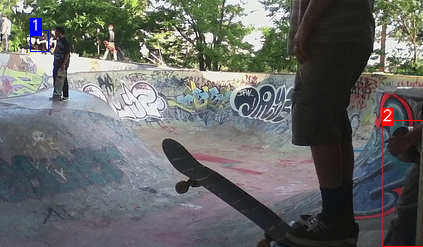

In [ ]:
# Load the image
img_orig, img_cropped, img, pair, boxes = data.get_random_pair(intersect=False)

# Create the prompt
prompt = "Analyze the provided image and the two annotated bounding boxes. Focus only on describing their spatial relationship:\n 1. **Position**: Describe the position of each entity in the image briefly (e.g., top-left, bottom-center).\n 2. **Relative Location**: How are the entities positioned relative to each other (e.g., above, below, next to)?\n 3. **Proximity**: Are they near, touching, or far apart?\n 4. **Direction**: Specify the direction (e.g., to the left of, diagonally above).\n Summarize the spatial relationship in the format: <rel>[spatial relationship]</rel>. For example: Entity 1 is <rel>above</rel> Entity 2."
print(prompt)
prompt = f"<|image|><|begin_of_text|>{prompt}"

# Set up sampling parameters
sampling_params = SamplingParams(temperature=0.1, max_tokens=150)

# Generate the response
inputs = {
    "prompt": prompt,
    "multi_modal_data": {
        "image": img_cropped
    },
}
outputs = llm.generate(inputs, sampling_params=sampling_params)

# Print the generated text
response = outputs[0].outputs[0].text
# get the relation between the <pred></pred> tags
print(response)
relation = response.split("<rel>")[1].split("</rel>")[0]
print(relation)
display(img_cropped)